# DSA 107 — Lab 1: Environment and first notebook

**Week 1 · w/c 28 September 2026** · paired with DSA 101 lecture week 1

**Name:** Andrei Tiniakov   **Student ID:** 26022121102

---

### What you will produce

A runnable Colab notebook, pushed to your own GitHub repository, that loads a dataset, answers four questions about it, and draws one labelled figure.

### Before you start

Run the setup cell below. If any import fails, run
`!pip install pandas matplotlib seaborn scikit-learn` in a new cell and try again.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 2.1.3


## 1. Load the data

`pd.read_csv` accepts a URL as happily as a filename. Load the penguins dataset into a DataFrame called `penguins`.

In [2]:
penguins = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")

# TODO: show the first five rows
print(penguins.head(5))

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


## 2. How big is it, and what is in it?

Three commands answer almost every first question about a dataset:

- `.shape` — rows and columns
- `.info()` — column names, types, and how many non-missing values each has
- `.describe()` — summary statistics for the numeric columns

In [3]:
# TODO: print the shape, then call .info()

#shape - prints a tuple (rows, columns)
print(penguins.shape)

print("---------")

#info() - prints a table that shows:
# colum names, column count, colum types (nullability, count, Dtype)
# and also metadata like memory, range (count of rows) dtypes
print(penguins.info())


print("---------")







(344, 7)
---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None
---------


In [4]:
# TODO: summary statistics for the numeric columns
#each property that can be desicribed with stats like min, max, count, mean etc are printed
# and their count, mean (avg), std (standard deviation - how spread values are around the mean), min, 25%, 50%, 75% (percentiles), max for each field (stats)
print(penguins.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


### Missing values

`.isna()` gives a True/False table the same shape as the data. Summing it down the columns counts the missing values in each.

In [5]:
# TODO: count the missing values in each column

# true in the table stands for null value, false values are non null
print(penguins.isna())


# .sum() gives us a summary that shows
print(penguins.isna().sum())

print("----------")

#by default .sum() passes axis=0 which counts each column seperetly
# we want to count each row which is why we need to pass axis=1
nulls_per_row = penguins.isna().sum(axis=1)
print(nulls_per_row)
#here we can see how many colums are null in each row

max_nulls = nulls_per_row.max()
print("Max nulls in one row:", max_nulls)

rows_with_max_nulls = (nulls_per_row == max_nulls).sum()

print("Number of rows with max nulls:", rows_with_max_nulls)


     species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0      False   False           False          False              False   
1      False   False           False          False              False   
2      False   False           False          False              False   
3      False   False            True           True               True   
4      False   False           False          False              False   
..       ...     ...             ...            ...                ...   
339    False   False            True           True               True   
340    False   False           False          False              False   
341    False   False           False          False              False   
342    False   False           False          False              False   
343    False   False           False          False              False   

     body_mass_g    sex  
0          False  False  
1          False  False  
2          False  False  
3      

**Q1.** How many penguins are in the dataset, and how many columns describe each one?


**Q2.** Which column has the most missing values, and how many? Suggest one plausible reason a field measurement might be missing.

*Write your answers here.*

A1: there are 344 penguines, and 7 columns

A2: most missing values are 5 and there are 2 rows that have 5 missing values
Reasons for missing values:
1) data set is not cleaed
2) some measurements were couldn not be taken

## 3. Selecting and filtering

A single column is `df["name"]`. Several columns is `df[["a", "b"]]` — note the double brackets. Rows are chosen with a condition: `df[df["col"] > 5]`.

In [6]:
# TODO: show only species, island and body_mass_g, first five rows
penguins[["species", "island", "body_mass_g"]].head(5)

,species,island,body_mass_g
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,3450.0


In [7]:
# TODO: make a DataFrame called gentoo holding only the Gentoo penguins,
# then print how many there are
gentoo = penguins[penguins["species"] == "Gentoo"]
gentoo.head(5)

print(len(gentoo))

124


**Q3.** How many Gentoo penguins are there? What fraction of the dataset is that?

In [8]:
# TODO: compute and print the fraction
print("there are", len(gentoo), "gentoo penguins")

print("Gento penguins are", (len(gentoo) / len(penguins)) * 100, "% of all penguins")



there are 124 gentoo penguins
Gento penguins are 36.04651162790697 % of all penguins


## 4. Your first figure

A scatter plot of two numeric columns, coloured by a third categorical one. Every figure in this course needs axis labels and a title — a plot without them is not a finished piece of work.

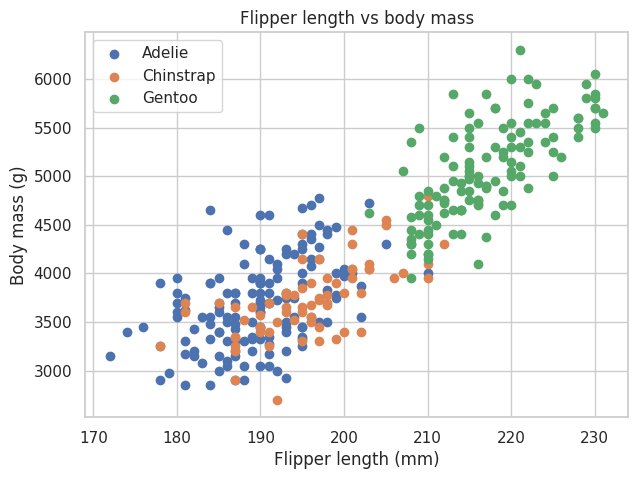

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
# TODO: scatter plot of flipper_length_mm against body_mass_g,
#       coloured by species, with labels and a title

ax.set_title("Flipper length vs body mass")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")

for species in penguins["species"].unique():
  group = penguins[penguins["species"] == species]
  ax.scatter(
    group["flipper_length_mm"],
    group["body_mass_g"],
    label=species
)

ax.legend()

plt.show()

**Q4.** Describe the relationship in two sentences. Does it hold within every species, or only across all three together? What would you check next?

Gentoo have highest body mass and flipper length. Adeile and Chinstrap are mostly the same, except for adelie sometimes having higher body mass and Chinstrap having longer flippers

## 5. Push to GitHub

1. Create a repository named `dsa107-labs` on GitHub (public is fine).
2. In Colab: **File → Save a copy in GitHub**, choose that repository.
3. Paste the resulting link in the cell below.

**Repository link:** https://github.com/AndrewTinyakov/dsa107-labs

---

## Submission checklist

- [ ] Every cell runs top to bottom without error (Runtime → Restart and run all)
- [ ] Every written answer is filled in — a plot with no reading of it scores zero on interpretation
- [ ] Notebook saved as `Lab01_Firstname_Lastname.ipynb`
- [ ] Report exported as `Lab01_Firstname_Lastname.pdf`
- [ ] If you used an AI assistant, the log is attached as described in the course AI policy

Submit both files through MS Teams.

AI usage:

---

what does mean and std mean in descirbe function?

In describe():
- mean is the average value.
- std is the standard deviation, which tells you how spread out the values are around the mean.
For example, for body_mass_g:
mean = 4201.75
std  = 801.95

So the average penguin weighs about 4202 g.
A standard deviation of about 802 g means penguin weights typically vary quite a lot around that average. Roughly speaking, many values are within:
4202 - 802 = 3400 g
4202 + 802 = 5004 g

So around 3400–5000 g.
For bill_length_mm:
mean = 43.92 mm
std  = 5.46 mm

Average bill length is about 43.9 mm, and values commonly differ from that average by about 5.5 mm.
One important thing: std does not mean the average difference exactly. It is a specific statistical measure of spread. The larger the std, the more spread out the data is.


---

how can i count those rows that have most nulls - how many null values they have and how many of them


You want to count missing values per row, then find the maximum.
nulls_per_row = penguins.isna().sum(axis=1)print(nulls_per_row)


The important part is axis=1, which means "sum across columns for each row."
Then find the largest number of nulls in any row:
max_nulls = nulls_per_row.max()print(max_nulls)


And count how many rows have that many nulls:
rows_with_max_nulls = (nulls_per_row == max_nulls).sum()print("Maximum nulls in one row:", max_nulls)print("Number of rows with that many nulls:", rows_with_max_nulls)


For this penguins dataset, you should get roughly:
Maximum nulls in one row: 5
Number of rows with that many nulls: 2

You can also see the actual rows:
penguins[nulls_per_row == max_nulls]


Or, if you want to see all rows ranked by how many nulls they contain:
penguins.isna().sum(axis=1).sort_values(ascending=False)


Think of the axes like this:
axis=0 → down the rows → result per COLUMN
axis=1 → across columns → result per ROW

So here, since you're asking "how many nulls does each row have?", you want axis=1.

---

What does the .sum() do? explain the difference with axis=1
show exmaples

.sum() adds values together.
The only tricky part is that with a DataFrame, pandas needs to know in which direction to add them.
Take this tiny example:
import pandas as pddf = pd.DataFrame({    "A": [1, 2, 3],    "B": [10, 20, 30]})print(df)


You get:
   A   B
0  1  10
1  2  20
2  3  30

Now:
df.sum()


is the same as:
df.sum(axis=0)


It adds downward, column by column:
A     6
B    60

Because:
A: 1 + 2 + 3 = 6
B: 10 + 20 + 30 = 60

But:
df.sum(axis=1)


adds across each row:
0    11
1    22
2    33

Because:
row 0: 1 + 10 = 11
row 1: 2 + 20 = 22
row 2: 3 + 30 = 33

So visually:
axis=0
   ↓
   A   B
0  1  10
1  2  20
2  3  30

sum:
A = 6
B = 60

axis=1
   →
   A   B
0  1  10   = 11
1  2  20   = 22
2  3  30   = 33

Now with your null example:
penguins.isna()


creates a table like:
       A      B      C
0   False   True   False
1    True   True   False
2   False  False   False

Python treats booleans as numbers when summing:
True  = 1
False = 0

So:
penguins.isna().sum()


means:
penguins.isna().sum(axis=0)


It counts nulls per column:
A    1
B    2
C    0

But:
penguins.isna().sum(axis=1)


counts nulls per row:
0    1
1    2
2    0

So the easiest rule to remember is:
.sum()         → add downward, per column
.sum(axis=0)   → same thing
.sum(axis=1)   → add sideways, per row

For your task:
penguins.isna().sum(axis=1)


means "for every penguin row, count how many columns are missing."

---
explain this part

lets start with this
fig, ax = plt.subplots(figsize=(7, 5))
# TODO: scatter plot of flipper_length_mm against body_mass_g,
#       coloured by species, with labels and a title
plt.show()

and then maybe explan to me some funcitons i need to call to do this task


Start with this line:
fig, ax = plt.subplots(figsize=(7, 5))


It creates an empty figure for you to draw on.
Think of it like:
fig = the whole image/canvas
ax  = the actual graph area inside the image

So:
fig, ax = plt.subplots(figsize=(7, 5))


means:
"Create a figure that is 7 inches wide and 5 inches tall, and give me the graph area as ax."

You will mostly use ax for this task.
1. Drawing a scatter plot
The main function is:
ax.scatter(x, y)


For example:
ax.scatter(    penguins["flipper_length_mm"],    penguins["body_mass_g"])


Here:
x = flipper_length_mm
y = body_mass_g

So every penguin becomes one dot:
                 body mass
                    ↑
                    |      •
                    |   •
                    | •    •
                    |•
                    +--------------→ flipper length

2. Giving the axes names
Your instructions say every graph needs axis labels.
Use:
ax.set_xlabel("Flipper length (mm)")ax.set_ylabel("Body mass (g)")


So now the reader knows what X and Y mean.
3. Giving the graph a title
Use:
ax.set_title("Flipper length vs body mass")


So your code so far could be:
fig, ax = plt.subplots(figsize=(7, 5))ax.scatter(    penguins["flipper_length_mm"],    penguins["body_mass_g"])ax.set_xlabel("Flipper length (mm)")ax.set_ylabel("Body mass (g)")ax.set_title("Flipper length vs body mass")plt.show()


plt.show() basically means:
"Okay, I'm done building the graph. Display it."

The remaining part of the task is:
coloured by species

That is slightly more interesting because you have three groups:
Adelie
Chinstrap
Gentoo

You need each species to have its own color.
One way with plain matplotlib is to loop through them:
for species in penguins["species"].unique():


.unique() gives you the different values that exist in a column:
penguins["species"].unique()


might give:
['Adelie', 'Chinstrap', 'Gentoo']

Then inside the loop you can filter:
group = penguins[penguins["species"] == species]


and draw that group:
ax.scatter(    group["flipper_length_mm"],    group["body_mass_g"],    label=species)


Finally:



shows which color belongs to which species.
So the functions worth knowing for this exercise are:
plt.subplots()       # create the graphax.scatter()         # put dots on the graphax.set_xlabel()      # name the X axisax.set_ylabel()      # name the Y axisax.set_title()       # add a titlecolumn.unique()      # find unique categories, like speciesax.legend()          # show what each color/group meansplt.show()           # display the finished graph


I would try building it yourself now using those pieces rather than copying the full final solution immediately. The only slightly tricky part is making the three species separate groups.

---



